In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 

# Set a clean visual style for all charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) # Makes all charts big and readable

In [2]:

#loading Data
deliveries=pd.read_csv("deliveries.csv")
matches=pd.read_csv("matches.csv")

In [3]:
print("Shape of Deliveries DataSet:",deliveries.shape)

Shape of Deliveries DataSet: (260920, 17)


In [4]:
print("Shape of Matches DataSet:",matches.shape)

Shape of Matches DataSet: (1095, 20)


In [5]:
# Viewing all Columns of Deliveries columns
print("Columns of Deliveries :\n",deliveries.columns)

Columns of Deliveries :
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='object')


In [6]:
# Viewing all Columns of Mathces columns
print("\nColumns of Matches :\n",matches.columns)


Columns of Matches :
 Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='object')


In [7]:
# Viewing all columns datatypes and null values
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [8]:
# printing first 5 rows
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# Datasets Summary is :

#### The `deliveries` dataset contains ball-by-ball IPL match data.
#### Each row represents one delivery bowled in a match.

#### The `matches` dataset contains match-level data for IPL tournaments.
#### Each row represents one IPL match, including teams, venue, season, and result.


# Six-Hitting Analysis 


In [9]:
# Calculating top 10 batters that hit the most sixes in IPL History

#Filtering Those Rows  having 6
sixes=deliveries[deliveries["batsman_runs"]==6]

# Sorting for top six hitters in IPL History
top_six_hitter=sixes.groupby("batter")["batsman_runs"].count().nlargest(10).reset_index().rename(columns={"batsman_runs":"total sixes"})
top_six_hitter

,batter,total sixes
0,CH Gayle,359
1,RG Sharma,281
2,V Kohli,273
3,AB de Villiers,253
4,MS Dhoni,252
5,DA Warner,236
6,KA Pollard,224
7,AD Russell,209
8,SV Samson,206
9,SK Raina,204


C:\Users\Umair\AppData\Local\Temp\ipykernel_20896\1746983632.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


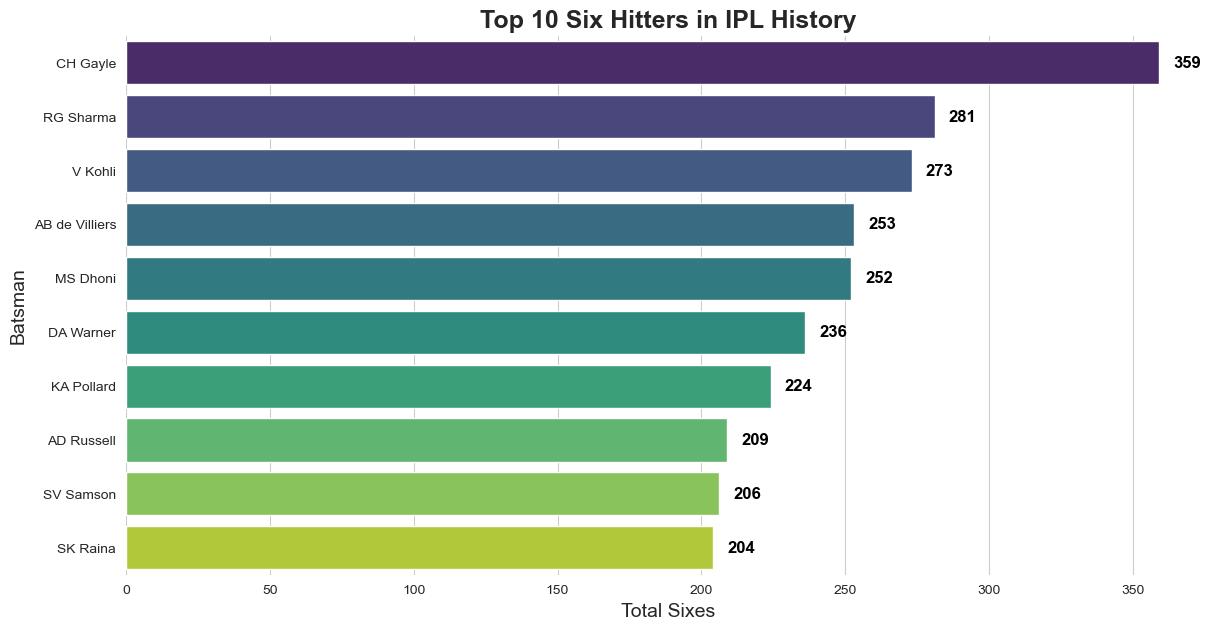

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Seting a clean style
sns.set_style("whitegrid") 

plt.figure(figsize=(14, 7))
ax = sns.barplot(
    x='total sixes', 
    y='batter', 
    data=top_six_hitter, # Used the original DF directly
    palette='viridis'
)

plt.title('Top 10 Six Hitters in IPL History', fontsize=18, fontweight='bold')
plt.xlabel('Total Sixes', fontsize=14)
plt.ylabel('Batsman', fontsize=14)

# Adding value labels (Your logic was perfect here!)
for index, value in enumerate(top_six_hitter['total sixes']):
    plt.text(value + 5, index, str(value), color='black', va='center', fontsize=12, fontweight='bold')

# Removing visual clutter (spines)
sns.despine(left=True, bottom=True)

plt.show()

In [11]:
# Consistency Filter for Good Batsmans

# Total runs per batter
total_runs = deliveries.groupby("batter")["batsman_runs"].sum()

# Total balls faced per batter
balls = deliveries.groupby("batter").size()

#Consistency Filter Logic
consistent_batter=total_runs[balls>=1000]
#Sorting top 10
consistent_batter.nlargest(10).reset_index()

,batter,batsman_runs
0,V Kohli,8014
1,S Dhawan,6769
2,RG Sharma,6630
3,DA Warner,6567
4,SK Raina,5536
5,MS Dhoni,5243
6,AB de Villiers,5181
7,CH Gayle,4997
8,RV Uthappa,4954
9,KD Karthik,4843


C:\Users\Umair\AppData\Local\Temp\ipykernel_20896\570862714.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


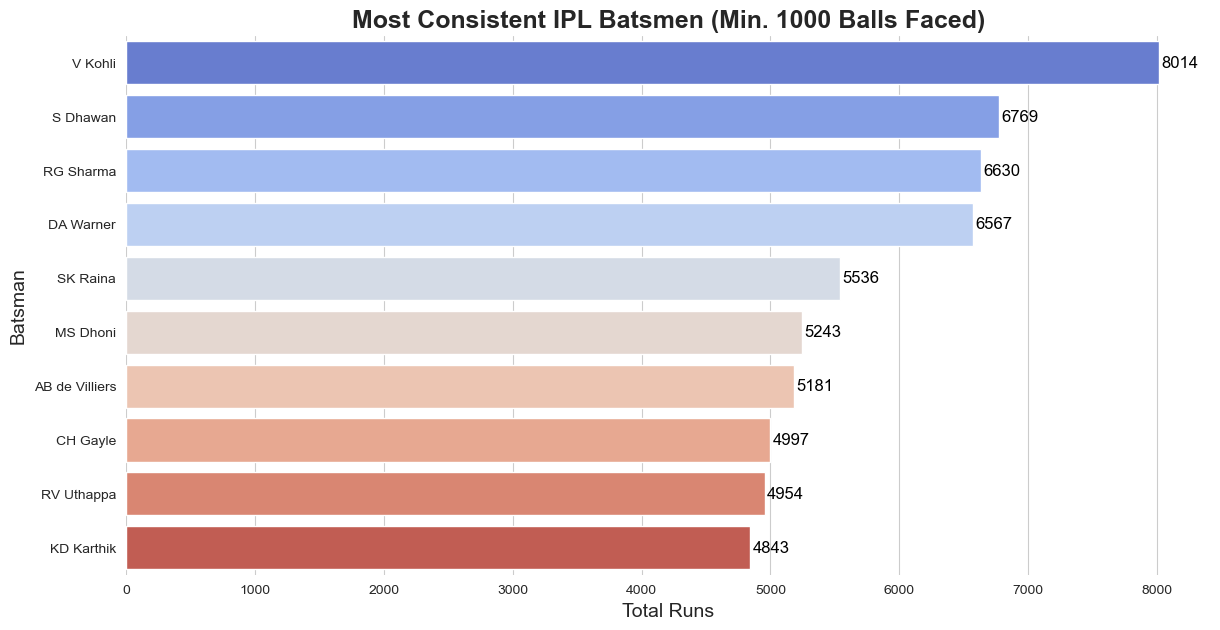

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- DATA PREPARATION (Your Logic) ---
# 1. Calculate Aggregates
total_runs = deliveries.groupby("batter")["batsman_runs"].sum()
balls = deliveries.groupby("batter").size()

# 2. Apply Consistency Filter (Min 500 balls)
consistent_batter = total_runs[balls >= 1000]

# 3. Sort and Reset Index for Plotting
# Storing in a new variable 'top_consistent'
top_consistent = consistent_batter.nlargest(10).reset_index()

# Rename columns for clarity (optional but recommended)
top_consistent.columns = ['batter', 'total_runs']

# --- VISUALIZATION ---
sns.set_style("whitegrid")
plt.figure(figsize=(14, 7))

# Create Horizontal Bar Plot
sns.barplot(
    x='total_runs', 
    y='batter', 
    data=top_consistent, 
    palette='coolwarm' # 'coolwarm' looks professional for performance metrics
)

# Titles and Labels
plt.title('Most Consistent IPL Batsmen (Min. 1000 Balls Faced)', fontsize=18, fontweight='bold')
plt.xlabel('Total Runs', fontsize=14)
plt.ylabel('Batsman', fontsize=14)

# Data Labels
for index, value in enumerate(top_consistent['total_runs']):
    plt.text(value + 20, index, str(value), color='black', va='center', fontsize=12)

# Clean up borders
sns.despine(left=True, bottom=True)

plt.show()

# 🔹 Strike Rate Leaders 

In [13]:
#Top 20 batters by strike rate (minimum 500 balls).

# Total Runs Socred by Each Batter

total_runs=deliveries.groupby("batter")["batsman_runs"].sum()

# Total Balls Faced by Each batter

balls=deliveries.groupby("batter").size()

# Strike Rate Logic 

strike_rate=(total_runs/balls)*100

fair_strike_rate=strike_rate[balls>=1000]

#Sorting and selecting Top 20
fair_strike_rate.nlargest(20).reset_index().rename(columns={0:"total_runs"})

,batter,total_runs
0,AD Russell,164.224422
1,N Pooran,154.768154
2,GJ Maxwell,150.488599
3,V Sehwag,148.827059
4,AB de Villiers,148.580442
5,YBK Jaiswal,146.757991
6,RR Pant,143.597561
7,PP Shaw,143.224830
8,SA Yadav,142.505948
9,JC Buttler,142.238984


C:\Users\Umair\AppData\Local\Temp\ipykernel_20896\803314781.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


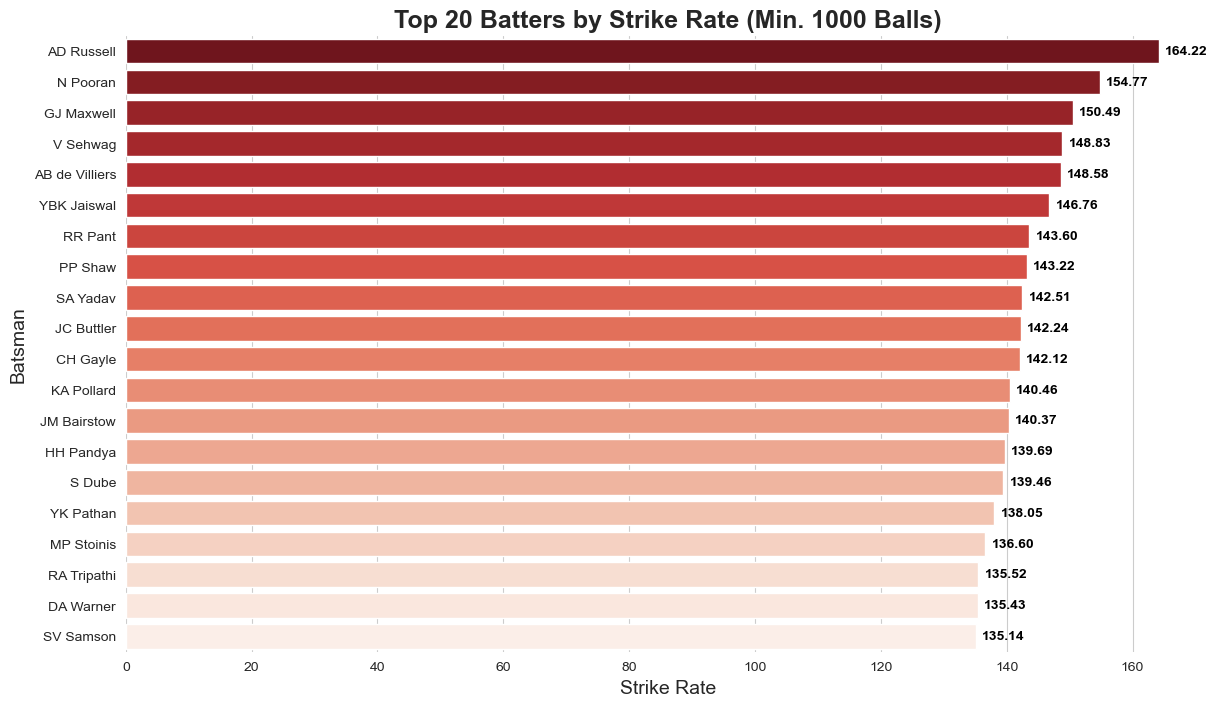

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- YOUR LOGIC ---
# 1. Calculate Runs and Balls
total_runs = deliveries.groupby("batter")["batsman_runs"].sum()
balls = deliveries.groupby("batter").size()

# 2. Calculate Strike Rate
strike_rate = (total_runs / balls) * 100

# 3. Filter for experienced players (Min 1000 balls)
fair_strike_rate = strike_rate[balls >= 1000]

# 4. Sort and Reset Index
# I changed the rename to 'strike_rate' because that is what the values represent!
top_20_sr = fair_strike_rate.nlargest(20).reset_index().rename(columns={0: "strike_rate"})
# If the Series name was inherited, the column might be named 'batsman_runs' or similar by default,
# so explicit renaming here ensures the plot works.
top_20_sr.columns = ['batter', 'strike_rate']

# --- VISUALIZATION ---
sns.set_style("whitegrid")
plt.figure(figsize=(14, 8))

# Horizontal Bar Plot
ax = sns.barplot(
    x='strike_rate',
    y='batter',
    data=top_20_sr,
    palette='Reds_r'  # 'Reds_r' (Reverse Reds) implies "Hot/Dangerous" batters
)

# Titles and Labels
plt.title('Top 20 Batters by Strike Rate (Min. 1000 Balls)', fontsize=18, fontweight='bold')
plt.xlabel('Strike Rate', fontsize=14)
plt.ylabel('Batsman', fontsize=14)

# Adding Data Labels (formatted to 2 decimal places)
for index, value in enumerate(top_20_sr['strike_rate']):
    plt.text(value + 1, index, f"{value:.2f}", color='black', va='center', fontsize=10, fontweight='bold')

# Remove borders
sns.despine(left=True, bottom=True)

plt.show()

In [15]:
# Bottom top 10 strike rates among batters who faced ≥ 500 balls.


# Total runs scored by each batter

total_runs=deliveries.groupby("batter")["batsman_runs"].sum()

# Total Balls Scored by each batter

balls=deliveries.groupby("batter").size()

#Strike Rate Logic

strike_rate=(total_runs/balls)*100

fair_strike_rate=strike_rate[balls>=500]

# Sorting and Selecting Bottom 10

fair_strike_rate.sort_values(ascending=True).head(10).reset_index()

,batter,0
0,SC Ganguly,101.734540
1,HH Gibbs,105.854241
2,JH Kallis,105.936272
3,GC Smith,106.946454
4,PP Chawla,107.586207
5,MS Bisla,108.276798
6,TM Dilshan,110.124164
7,R Dravid,113.347237
8,MK Tiwary,113.834788
9,Y Venugopal Rao,113.872832
